In [1]:
pip install pandas matplotlib ipykernel

  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl (9.8 MB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 11.3 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 11.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.1 MB/s  0:00:00
Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl (12.7 M

In [1]:
pip install -r "requirements[1].txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'comando para instalar tudo de uma vez: pip install (nome da biblioteca)': Expected semicolon (after name with no version specifier) or end
    comando para instalar tudo de uma vez: pip install (nome da biblioteca)
            ^ (from line 18 of requirements[1].txt)


In [1]:
# CARREGAR E CONHECER DADOS
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("impacto_ia_redes_sociais_estudantes.csv")
df = df.rename(columns={"pontuação_fisica": "pontuacao_fisica"})

In [2]:
df.head()

,id_estudante,idade,genero,escolaridade,horas_redes_sociais,horas_ia,horas_sono,horas_atividade_fisica,pontuacao_mental,pontuacao_fisica
0,STU_00001,19,Masculino,Faculdade,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Nao binario,Ensino Medio,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Masculino,Universidade,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Masculino,Universidade,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Nao binario,Faculdade,6.52,1.64,5.23,1.14,67.74,88.04


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_estudante            16000 non-null  str    
 1   idade                   16000 non-null  int64  
 2   genero                  16000 non-null  str    
 3   escolaridade            16000 non-null  str    
 4   horas_redes_sociais     16000 non-null  float64
 5   horas_ia                16000 non-null  float64
 6   horas_sono              16000 non-null  float64
 7   horas_atividade_fisica  16000 non-null  float64
 8   pontuacao_mental        16000 non-null  float64
 9   pontuacao_fisica        16000 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 1.2 MB


In [4]:
print("Nulos por coluna:")
print(df.isna().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())

Nulos por coluna:
id_estudante              0
idade                     0
genero                    0
escolaridade              0
horas_redes_sociais       0
horas_ia                  0
horas_sono                0
horas_atividade_fisica    0
pontuacao_mental          0
pontuacao_fisica          0
dtype: int64

Linhas duplicadas: 0


In [5]:
df.describe()

,idade,horas_redes_sociais,horas_ia,horas_sono,horas_atividade_fisica,pontuacao_mental,pontuacao_fisica
count,16000.00000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,19.03875,4.541791,2.590624,6.545371,1.248359,72.493193,88.020465
std,3.76527,2.403044,1.679376,1.270515,1.038632,9.244818,9.691037
min,13.00000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000
25%,16.00000,2.840000,1.310000,5.680000,0.310000,66.760000,81.517500
50%,19.00000,4.500000,2.520000,6.540000,1.130000,73.750000,89.455000
75%,22.00000,6.180000,3.750000,7.410000,1.960000,79.550000,97.170000
max,25.00000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000


In [7]:
# MÉDIA E MEDIANA
colunas_numericas = [
    "idade",
    "horas_redes_sociais",
    "horas_ia",
    "horas_sono",
    "horas_atividade_fisica",
    "pontuacao_mental",
    "pontuacao_fisica",
]

for coluna in colunas_numericas:
    media = df[coluna].mean()
    mediana = df[coluna].median()
    print(f"{coluna}: média = {media:.2f} | mediana = {mediana:.2f}")

idade: média = 19.04 | mediana = 19.00
horas_redes_sociais: média = 4.54 | mediana = 4.50
horas_ia: média = 2.59 | mediana = 2.52
horas_sono: média = 6.55 | mediana = 6.54
horas_atividade_fisica: média = 1.25 | mediana = 1.13
pontuacao_mental: média = 72.49 | mediana = 73.75
pontuacao_fisica: média = 88.02 | mediana = 89.45


In [8]:
#QUARTIS, IQR, LIMIAR E OUTLIERS

for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)   # Q2 = mediana
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"--- {coluna} ---")
    print(f"Q1 = {q1:.2f} | Q2 = {q2:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}")
    print(f"LI = {limite_inferior:.2f} | LS = {limite_superior:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}% das linhas)\n")

--- idade ---
Q1 = 16.00 | Q2 = 19.00 | Q3 = 22.00 | IQR = 6.00
LI = 7.00 | LS = 31.00
Outliers: 0 (0.00% das linhas)

--- horas_redes_sociais ---
Q1 = 2.84 | Q2 = 4.50 | Q3 = 6.18 | IQR = 3.34
LI = -2.17 | LS = 11.19
Outliers: 49 (0.31% das linhas)

--- horas_ia ---
Q1 = 1.31 | Q2 = 2.52 | Q3 = 3.75 | IQR = 2.44
LI = -2.35 | LS = 7.41
Outliers: 51 (0.32% das linhas)

--- horas_sono ---
Q1 = 5.68 | Q2 = 6.54 | Q3 = 7.41 | IQR = 1.73
LI = 3.08 | LS = 10.01
Outliers: 105 (0.66% das linhas)

--- horas_atividade_fisica ---
Q1 = 0.31 | Q2 = 1.13 | Q3 = 1.96 | IQR = 1.65
LI = -2.16 | LS = 4.43
Outliers: 55 (0.34% das linhas)

--- pontuacao_mental ---
Q1 = 66.76 | Q2 = 73.75 | Q3 = 79.55 | IQR = 12.79
LI = 47.58 | LS = 98.73
Outliers: 185 (1.16% das linhas)

--- pontuacao_fisica ---
Q1 = 81.52 | Q2 = 89.45 | Q3 = 97.17 | IQR = 15.65
LI = 58.04 | LS = 120.65
Outliers: 63 (0.39% das linhas)



In [9]:
# AMPLITUDE, VARIANCIA E DESVIO PADRÃO

for coluna in colunas_numericas:
    amplitude = df[coluna].max() - df[coluna].min()
    variancia = df[coluna].var()
    desvio_padrao = df[coluna].std()

    print(f"--- {coluna} ---")
    print(f"Amplitude total = {amplitude:.2f}")
    print(f"Variância = {variancia:.2f} | Desvio padrão = {desvio_padrao:.2f}\n")

--- idade ---
Amplitude total = 12.00
Variância = 14.18 | Desvio padrão = 3.77

--- horas_redes_sociais ---
Amplitude total = 14.00
Variância = 5.77 | Desvio padrão = 2.40

--- horas_ia ---
Amplitude total = 9.50
Variância = 2.82 | Desvio padrão = 1.68

--- horas_sono ---
Amplitude total = 9.15
Variância = 1.61 | Desvio padrão = 1.27

--- horas_atividade_fisica ---
Amplitude total = 5.00
Variância = 1.08 | Desvio padrão = 1.04

--- pontuacao_mental ---
Amplitude total = 59.20
Variância = 85.47 | Desvio padrão = 9.24

--- pontuacao_fisica ---
Amplitude total = 51.95
Variância = 93.92 | Desvio padrão = 9.69



In [10]:
#ASSIMETRIA E CURTOSE

for coluna in colunas_numericas:
    assimetria = df[coluna].skew()
    curtose_excesso = df[coluna].kurt()
    curtose_real = curtose_excesso + 3
    print(f"--- {coluna} ---")
    print(f"Assimetria = {assimetria:.3f}")
    print(f"Curtose em excesso = {curtose_excesso:.3f} | Curtose real = {curtose_real:.3f}\n")

--- idade ---
Assimetria = -0.011
Curtose em excesso = -1.218 | Curtose real = 1.782

--- horas_redes_sociais ---
Assimetria = 0.157
Curtose em excesso = -0.348 | Curtose real = 2.652

--- horas_ia ---
Assimetria = 0.338
Curtose em excesso = -0.369 | Curtose real = 2.631

--- horas_sono ---
Assimetria = 0.015
Curtose em excesso = -0.005 | Curtose real = 2.995

--- horas_atividade_fisica ---
Assimetria = 0.619
Curtose em excesso = -0.273 | Curtose real = 2.727

--- pontuacao_mental ---
Assimetria = -0.683
Curtose em excesso = 0.244 | Curtose real = 3.244

--- pontuacao_fisica ---
Assimetria = -0.749
Curtose em excesso = -0.038 | Curtose real = 2.962



In [11]:
#RESUMO COM TABELA

def resumo_estatistico(coluna):
    """Recebe o nome de uma coluna numérica e devolve um dicionário com todas as medidas."""
    serie = df[coluna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    qtd_outliers = ((serie < li) | (serie > ls)).sum()

    return {
        "média": serie.mean(),
        "mediana": serie.median(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LI": li,
        "LS": ls,
        "outliers": qtd_outliers,
        "amplitude": serie.max() - serie.min(),
        "variância": serie.var(),
        "desvio padrão": serie.std(),
        "assimetria": serie.skew(),
        "curtose (excesso)": serie.kurt(),
    }

resumo = pd.DataFrame({coluna: resumo_estatistico(coluna) for coluna in colunas_numericas}).T
resumo.round(2)

,média,mediana,Q1,Q3,IQR,LI,LS,outliers,amplitude,variância,desvio padrão,assimetria,curtose (excesso)
idade,19.04,19.00,16.00,22.00,6.00,7.00,31.00,0.0,12.00,14.18,3.77,-0.01,-1.22
horas_redes_sociais,4.54,4.50,2.84,6.18,3.34,-2.17,11.19,49.0,14.00,5.77,2.40,0.16,-0.35
horas_ia,2.59,2.52,1.31,3.75,2.44,-2.35,7.41,51.0,9.50,2.82,1.68,0.34,-0.37
horas_sono,6.55,6.54,5.68,7.41,1.73,3.08,10.01,105.0,9.15,1.61,1.27,0.01,-0.01
horas_atividade_fisica,1.25,1.13,0.31,1.96,1.65,-2.16,4.43,55.0,5.00,1.08,1.04,0.62,-0.27
pontuacao_mental,72.49,73.75,66.76,79.55,12.79,47.58,98.73,185.0,59.20,85.47,9.24,-0.68,0.24
pontuacao_fisica,88.02,89.46,81.52,97.17,15.65,58.04,120.65,63.0,51.95,93.92,9.69,-0.75,-0.04


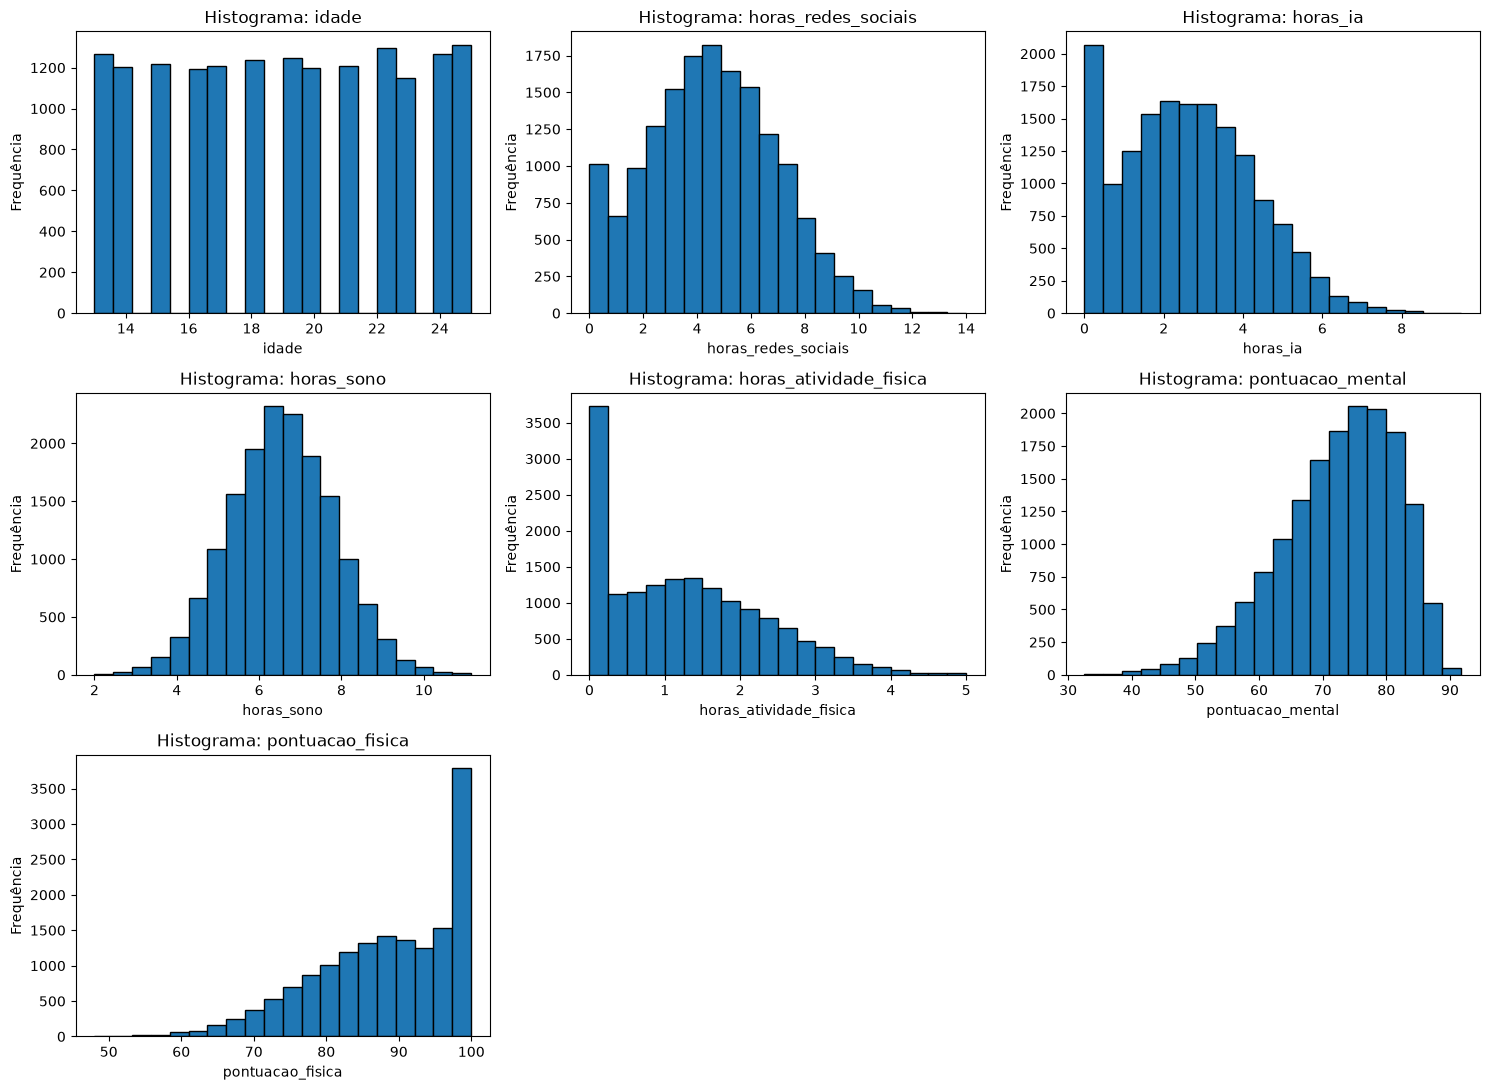

In [14]:
#HISTOGRAMA

fig, eixos = plt.subplots(3, 3, figsize=(15, 11))
eixos = eixos.flatten()

for i, coluna in enumerate(colunas_numericas):
    eixos[i].hist(df[coluna], bins=20, edgecolor="black")
    eixos[i].set_title(f"Histograma: {coluna}")
    eixos[i].set_xlabel(coluna)
    eixos[i].set_ylabel("Frequência")

for j in range(len(colunas_numericas), len(eixos)):
    eixos[j].axis("off")   # esconde os quadros vazios

plt.tight_layout()
plt.show()

C:\Users\marcc\AppData\Local\Temp\ipykernel_26120\772428809.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[i].boxplot(df[coluna], vert=False)
C:\Users\marcc\AppData\Local\Temp\ipykernel_26120\772428809.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[i].boxplot(df[coluna], vert=False)
C:\Users\marcc\AppData\Local\Temp\ipykernel_26120\772428809.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[i].boxplot(df[coluna], vert=False)
C:\Users\marcc\AppData\Local\Temp\ipykernel_26120\772428809.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'h

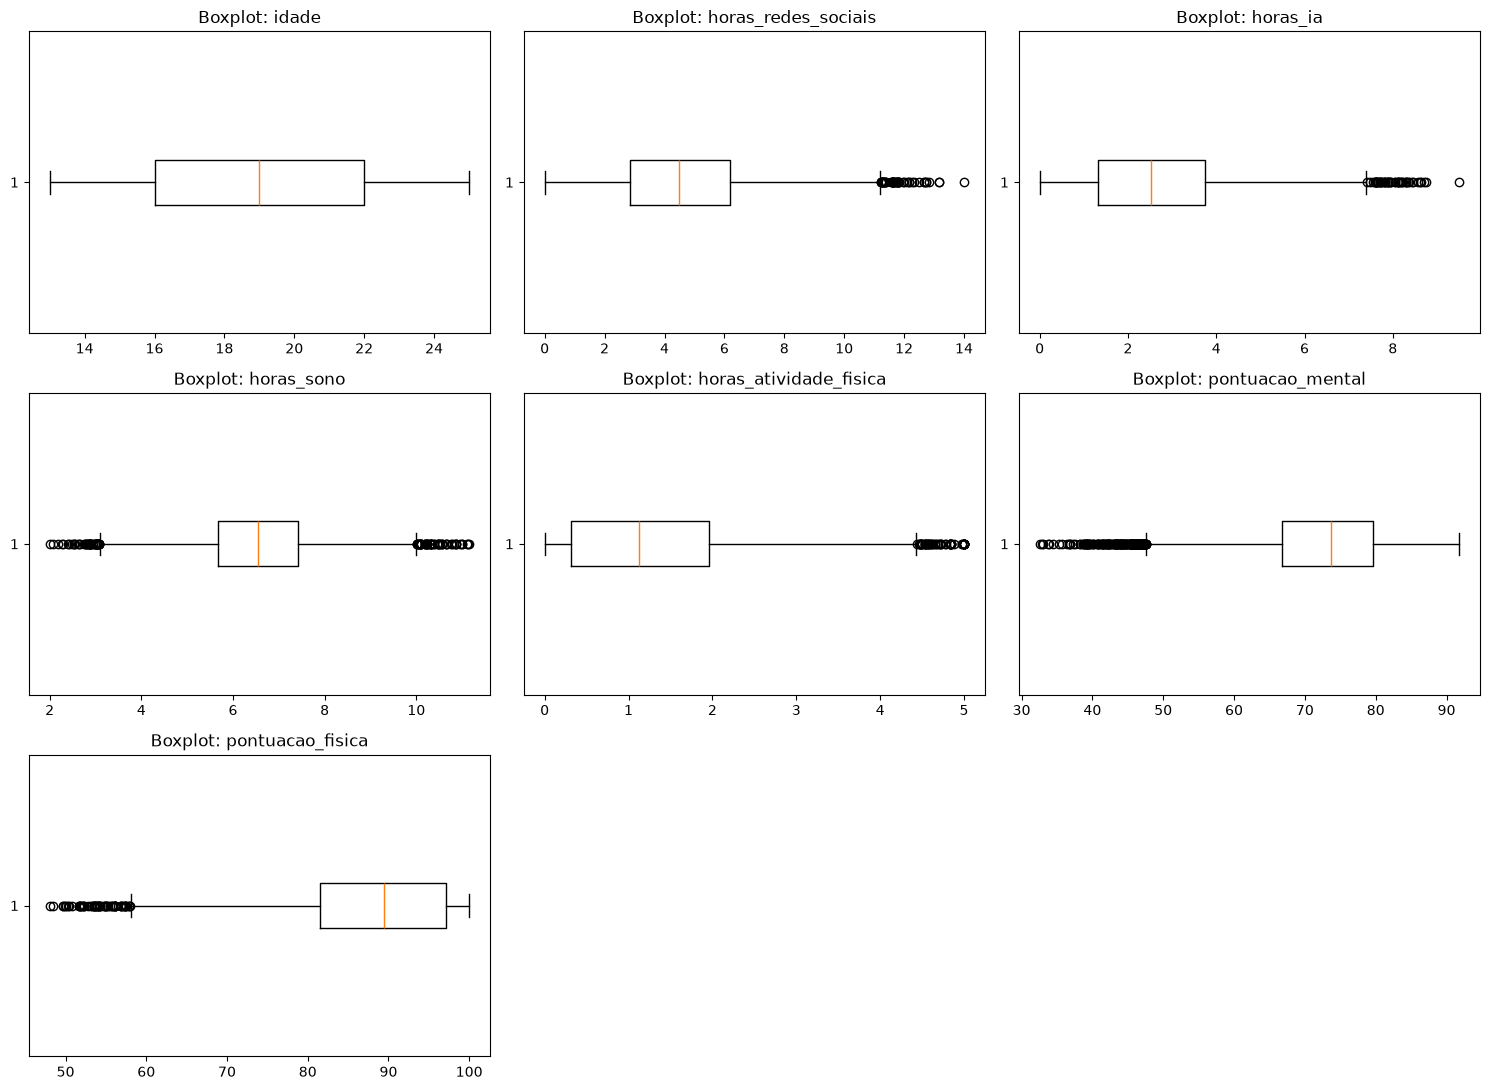

In [13]:
#BOXPLOT

fig, eixos = plt.subplots(3, 3, figsize=(15, 11))
eixos = eixos.flatten()

for i, coluna in enumerate(colunas_numericas):
    eixos[i].boxplot(df[coluna], vert=False)
    eixos[i].set_title(f"Boxplot: {coluna}")

for j in range(len(colunas_numericas), len(eixos)):
    eixos[j].axis("off")

plt.tight_layout()
plt.show()

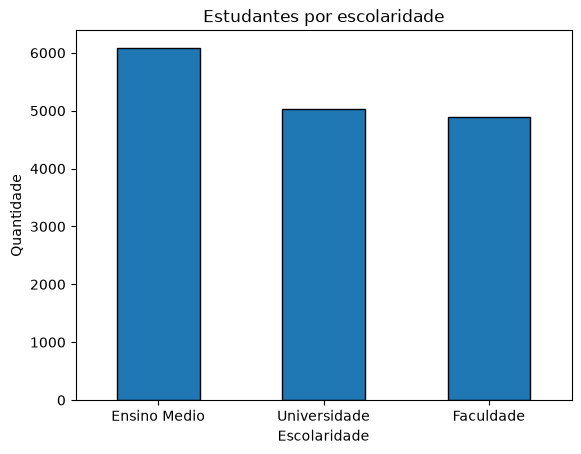

In [15]:
#GRAFICO BARRAS

# Quantidade de estudantes por escolaridade
df["escolaridade"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Estudantes por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

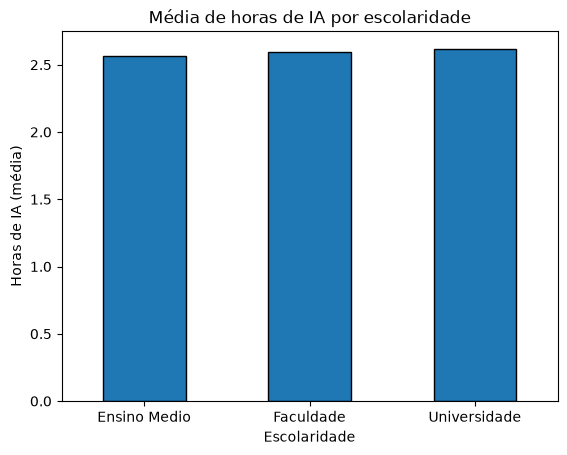

In [16]:
# Média de horas de IA por escolaridade
df.groupby("escolaridade")["horas_ia"].mean().plot(kind="bar", edgecolor="black")
plt.title("Média de horas de IA por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Horas de IA (média)")
plt.xticks(rotation=0)
plt.show()

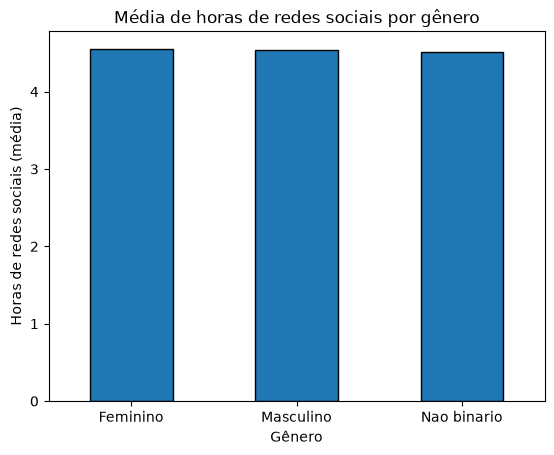

In [17]:
# Média de horas de redes sociais por gênero
df.groupby("genero")["horas_redes_sociais"].mean().plot(kind="bar", edgecolor="black")
plt.title("Média de horas de redes sociais por gênero")
plt.xlabel("Gênero")
plt.ylabel("Horas de redes sociais (média)")
plt.xticks(rotation=0)
plt.show()

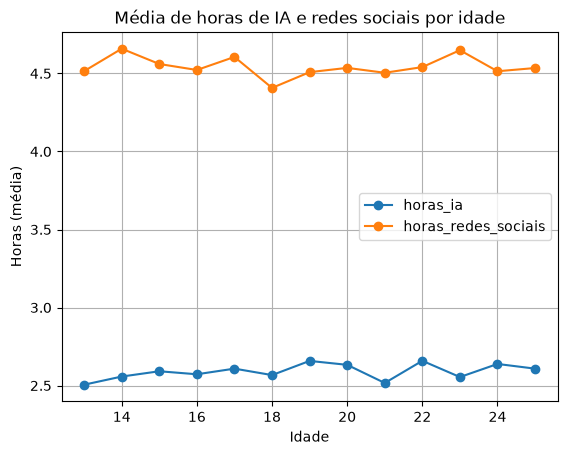

In [18]:
# GRAFICO DE LINHAS


# Média de horas de IA e de redes sociais por idade
df.groupby("idade")[["horas_ia", "horas_redes_sociais"]].mean().plot(kind="line", marker="o")
plt.title("Média de horas de IA e redes sociais por idade")
plt.xlabel("Idade")
plt.ylabel("Horas (média)")
plt.grid(True)
plt.show()